# Building Your First Artificial Neuron

---

In this walkthrough, we'll build an artificial neuron from scratch. By the end, you'll understand exactly how these fundamental building blocks of deep learning work.

## Part 1: Conceptual Review

### The Biological Neuron
Your brain has about 86 billion neurons. Each one:
- **Receives signals** through dendrites (inputs)
- **Processes them** in the cell body (weighted sum)
- **Decides whether to fire** based on a threshold (activation)
- **Sends output** through the axon (output)

### The Artificial Neuron
We mimic this with math:
- **Inputs (x):** Data coming in
- **Weights (w):** How important each input is
- **Bias (b):** A baseline adjustment
- **Activation Function:** The decision maker

**The Formula:**
```
output = activation( (x₁ × w₁) + (x₂ × w₂) + ... + bias )
```

## Part 2: The Math Behind It

Let's work through a simple example by hand first.

### Example: A neuron with 3 inputs

**Inputs:** `[0.5, 0.8, 0.2]`

**Weights:** `[0.4, 0.6, 0.3]`

**Bias:** `0.1`

**Step 1: Calculate the weighted sum**
```
z = (0.5 × 0.4) + (0.8 × 0.6) + (0.2 × 0.3) + 0.1
z = 0.2 + 0.48 + 0.06 + 0.1
z = 0.84
```

**Step 2: Apply activation function**

For now, let's use a simple rule: if z > 0.5, output 1 (fire!), otherwise output 0.
```
Since 0.84 > 0.5, output = 1
```

That's it! The neuron "fired."

## Part 3: Building a Neuron from Scratch

Now let's do this in Python!

In [1]:
# First, let's import numpy for our math operations
import numpy as np

print("Ready to build our neuron!")

Ready to build our neuron!


### Step 1: Define our inputs

In [2]:
# Our inputs - think of these as sensor readings or data points
inputs = np.array([0.5, 0.8, 0.2])

print("Inputs:", inputs)
print("Number of inputs:", len(inputs))

Inputs: [0.5 0.8 0.2]
Number of inputs: 3


### Step 2: Initialize weights

Weights determine how important each input is. In real neural networks, these are *learned* through training. For now, we'll set them manually.

In [3]:
# Weights - one for each input
weights = np.array([0.4, 0.6, 0.3])

print("Weights:", weights)
print("\nEach input gets multiplied by its corresponding weight:")
for i in range(len(inputs)):
    print(f"  Input {i+1}: {inputs[i]} × {weights[i]} = {inputs[i] * weights[i]}")

Weights: [0.4 0.6 0.3]

Each input gets multiplied by its corresponding weight:
  Input 1: 0.5 × 0.4 = 0.2
  Input 2: 0.8 × 0.6 = 0.48
  Input 3: 0.2 × 0.3 = 0.06


### Step 3: Add a bias term

The bias is like a baseline - it shifts the neuron's activation threshold.

In [4]:
# Bias - a single value that gets added at the end
bias = 0.1

print("Bias:", bias)

Bias: 0.1


### Step 4: Calculate the weighted sum

This is where we combine everything!

In [5]:
# Calculate weighted sum: (inputs × weights) + bias
weighted_sum = np.dot(inputs, weights) + bias

print("Calculation:")
print(f"  ({inputs[0]} × {weights[0]}) + ({inputs[1]} × {weights[1]}) + ({inputs[2]} × {weights[2]}) + {bias}")
print(f"  = {inputs[0]*weights[0]} + {inputs[1]*weights[1]} + {inputs[2]*weights[2]} + {bias}")
print(f"  = {weighted_sum}")
print(f"\nWeighted Sum (z): {weighted_sum}")

Calculation:
  (0.5 × 0.4) + (0.8 × 0.6) + (0.2 × 0.3) + 0.1
  = 0.2 + 0.48 + 0.06 + 0.1
  = 0.8400000000000001

Weighted Sum (z): 0.8400000000000001


### Step 5: Apply an activation function

The activation function decides if the neuron "fires" or not. Let's try two different ones:

**Step Function:** Simple on/off (1 or 0)

**Sigmoid Function:** Smooth curve between 0 and 1

In [6]:
# Step Function: if z > 0.5, output 1, else output 0
def step_function(z):
    return 1 if z > 0.5 else 0

# Sigmoid Function: smooth curve between 0 and 1
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

print("Activation Functions:")
print(f"  Step function output: {step_function(weighted_sum)}")
print(f"  Sigmoid output: {sigmoid(weighted_sum):.4f}")

Activation Functions:
  Step function output: 1
  Sigmoid output: 0.6985


### Step 6: Putting it all together - Our complete neuron!

In [7]:
def artificial_neuron(inputs, weights, bias, activation='sigmoid'):
    """
    A complete artificial neuron.
    
    Parameters:
    - inputs: array of input values
    - weights: array of weights (same length as inputs)
    - bias: single bias value
    - activation: 'sigmoid' or 'step'
    
    Returns:
    - The neuron's output
    """
    # Step 1: Calculate weighted sum
    z = np.dot(inputs, weights) + bias
    
    # Step 2: Apply activation function
    if activation == 'sigmoid':
        output = 1 / (1 + np.exp(-z))
    else:  # step function
        output = 1 if z > 0.5 else 0
    
    return output

# Test our neuron
result = artificial_neuron(inputs, weights, bias)
print(f"Neuron output: {result:.4f}")

Neuron output: 0.6985


## Part 4: Making It Interactive

Let's see how changing inputs and weights affects the output!

In [8]:
# Experiment 1: Change the inputs
print("=" * 50)
print("EXPERIMENT 1: Changing Inputs")
print("=" * 50)

# Same weights and bias
weights = np.array([0.4, 0.6, 0.3])
bias = 0.1

# Different input scenarios
test_inputs = [
    np.array([0.0, 0.0, 0.0]),  # All zeros
    np.array([1.0, 1.0, 1.0]),  # All ones
    np.array([0.5, 0.5, 0.5]),  # All medium
    np.array([1.0, 0.0, 0.0]),  # Only first input
    np.array([0.0, 1.0, 0.0]),  # Only second input
]

for inp in test_inputs:
    output = artificial_neuron(inp, weights, bias)
    print(f"Inputs: {inp} → Output: {output:.4f}")

EXPERIMENT 1: Changing Inputs
Inputs: [0. 0. 0.] → Output: 0.5250
Inputs: [1. 1. 1.] → Output: 0.8022
Inputs: [0.5 0.5 0.5] → Output: 0.6792
Inputs: [1. 0. 0.] → Output: 0.6225
Inputs: [0. 1. 0.] → Output: 0.6682


In [9]:
# Experiment 2: Change the weights
print("=" * 50)
print("EXPERIMENT 2: Changing Weights")
print("=" * 50)

# Same inputs and bias
inputs = np.array([0.5, 0.8, 0.2])
bias = 0.1

# Different weight scenarios
test_weights = [
    np.array([0.4, 0.6, 0.3]),   # Original
    np.array([1.0, 0.0, 0.0]),   # Only first input matters
    np.array([0.0, 1.0, 0.0]),   # Only second input matters
    np.array([0.33, 0.33, 0.33]),# Equal importance
    np.array([-0.5, 0.5, 0.5]),  # First input is negative!
]

for w in test_weights:
    output = artificial_neuron(inputs, w, bias)
    print(f"Weights: {w} → Output: {output:.4f}")

EXPERIMENT 2: Changing Weights
Weights: [0.4 0.6 0.3] → Output: 0.6985
Weights: [1. 0. 0.] → Output: 0.6457
Weights: [0. 1. 0.] → Output: 0.7109
Weights: [0.33 0.33 0.33] → Output: 0.6445
Weights: [-0.5  0.5  0.5] → Output: 0.5866


### Visualizing the Sigmoid Function

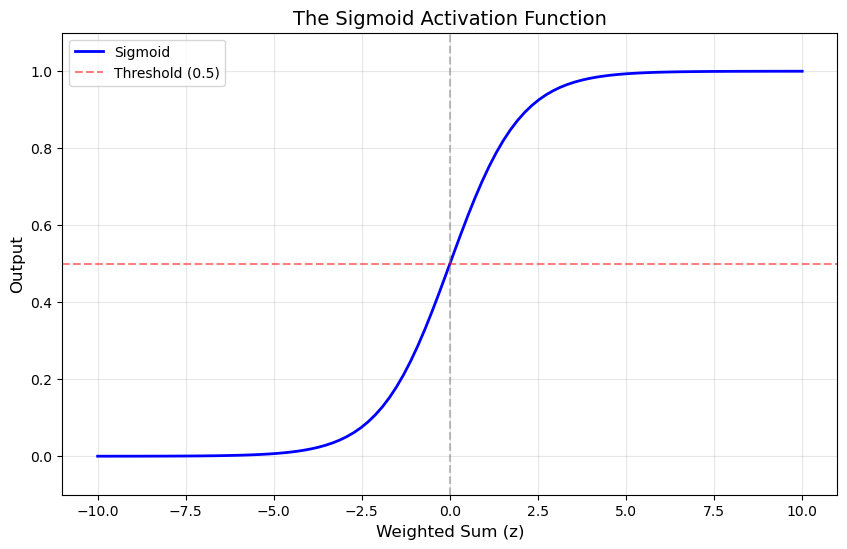

Notice how:
  - Large negative values → output close to 0
  - Large positive values → output close to 1
  - Values near 0 → output around 0.5


In [10]:
import matplotlib.pyplot as plt

# Create values from -10 to 10
z_values = np.linspace(-10, 10, 100)
sigmoid_values = 1 / (1 + np.exp(-z_values))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(z_values, sigmoid_values, 'b-', linewidth=2, label='Sigmoid')
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Threshold (0.5)')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Weighted Sum (z)', fontsize=12)
plt.ylabel('Output', fontsize=12)
plt.title('The Sigmoid Activation Function', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-0.1, 1.1)
plt.show()

print("Notice how:")
print("  - Large negative values → output close to 0")
print("  - Large positive values → output close to 1")
print("  - Values near 0 → output around 0.5")

## Part 5: A Simple Decision Example

Let's build a neuron that decides: **"Should I go outside?"**

### Inputs:
- **Weather quality** (0 = terrible, 1 = perfect)
- **Energy level** (0 = exhausted, 1 = energized)
- **Free time** (0 = busy, 1 = free)

### Your Task:
Adjust the weights based on what matters most to YOU!

In [11]:
def should_go_outside(weather, energy, free_time, weights, threshold=0.5):
    """
    A neuron that decides if you should go outside.
    
    Parameters:
    - weather: 0.0 to 1.0 (terrible to perfect)
    - energy: 0.0 to 1.0 (exhausted to energized)
    - free_time: 0.0 to 1.0 (busy to free)
    - weights: [weather_weight, energy_weight, free_time_weight]
    - threshold: decision boundary (default 0.5)
    
    Returns:
    - Decision and confidence
    """
    inputs = np.array([weather, energy, free_time])
    bias = -0.3  # Makes it slightly harder to decide "yes"
    
    # Calculate output
    z = np.dot(inputs, weights) + bias
    confidence = 1 / (1 + np.exp(-z))
    
    decision = "GO OUTSIDE!" if confidence > threshold else "Stay inside."
    
    return decision, confidence


# Example: What matters to you?
# Try adjusting these weights!
my_weights = np.array([
    0.5,   # How much does weather matter to you?
    0.3,   # How much does your energy level matter?
    0.4    # How much does having free time matter?
])

print("=" * 50)
print("SHOULD I GO OUTSIDE? - Decision Neuron")
print("=" * 50)
print(f"\nYour weights: Weather={my_weights[0]}, Energy={my_weights[1]}, Free Time={my_weights[2]}")
print("\n")

SHOULD I GO OUTSIDE? - Decision Neuron

Your weights: Weather=0.5, Energy=0.3, Free Time=0.4




In [12]:
# Test different scenarios
scenarios = [
    {"name": "Perfect day, energized, free", "weather": 1.0, "energy": 1.0, "free_time": 1.0},
    {"name": "Rainy, tired, busy", "weather": 0.2, "energy": 0.2, "free_time": 0.1},
    {"name": "Nice day, tired, free", "weather": 0.8, "energy": 0.3, "free_time": 0.9},
    {"name": "Okay weather, energized, busy", "weather": 0.5, "energy": 0.9, "free_time": 0.2},
    {"name": "Perfect weather, medium energy, medium time", "weather": 1.0, "energy": 0.5, "free_time": 0.5},
]

for scenario in scenarios:
    decision, confidence = should_go_outside(
        scenario["weather"], 
        scenario["energy"], 
        scenario["free_time"],
        my_weights
    )
    print(f"{scenario['name']}")
    print(f"  Weather={scenario['weather']}, Energy={scenario['energy']}, Free Time={scenario['free_time']}")
    print(f"  → {decision} (confidence: {confidence:.2%})")
    print()

Perfect day, energized, free
  Weather=1.0, Energy=1.0, Free Time=1.0
  → GO OUTSIDE! (confidence: 71.09%)

Rainy, tired, busy
  Weather=0.2, Energy=0.2, Free Time=0.1
  → Stay inside. (confidence: 47.50%)

Nice day, tired, free
  Weather=0.8, Energy=0.3, Free Time=0.9
  → GO OUTSIDE! (confidence: 63.41%)

Okay weather, energized, busy
  Weather=0.5, Energy=0.9, Free Time=0.2
  → GO OUTSIDE! (confidence: 57.44%)

Perfect weather, medium energy, medium time
  Weather=1.0, Energy=0.5, Free Time=0.5
  → GO OUTSIDE! (confidence: 63.41%)



### Try It Yourself!

Adjust the weights below to match YOUR decision-making style:

In [13]:
# YOUR TURN: Adjust these weights!
# Higher weight = that factor matters MORE to your decision

your_weights = np.array([
    0.7,   # Weather importance (try values 0.0 to 1.0)
    0.1,   # Energy importance
    0.9    # Free time importance
])

# Test with your current situation
current_weather = 0.7    # How's the weather right now?
current_energy = 0.6     # How energized do you feel?
current_free_time = 0.8  # How much free time do you have?

decision, confidence = should_go_outside(
    current_weather, 
    current_energy, 
    current_free_time,
    your_weights
)

print(f"\nYour current situation:")
print(f"  Weather: {current_weather}, Energy: {current_energy}, Free Time: {current_free_time}")
print(f"\nThe neuron says: {decision}")
print(f"Confidence: {confidence:.2%}")


Your current situation:
  Weather: 0.7, Energy: 0.6, Free Time: 0.8

The neuron says: GO OUTSIDE!
Confidence: 72.51%


## Part 6: Key Takeaways

### What We Learned:

1. **One neuron = one simple decision**
   - Takes inputs, weighs them, and produces an output

2. **Weights determine importance**
   - Higher weight = that input matters more
   - In real neural networks, weights are *learned* from data

3. **Activation functions add non-linearity**
   - Step function: hard yes/no
   - Sigmoid: smooth probability between 0 and 1

4. **Bias shifts the threshold**
   - Makes it easier or harder for the neuron to "fire"

### What's Next?

**Stack many neurons together = Neural Network**

- Layer 1 neurons detect simple patterns
- Layer 2 neurons combine those into more complex patterns
- And so on... this is what makes deep learning "deep"!

---

**Congratulations!** You now understand the fundamental building block of all neural networks!